In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns

In [50]:
import pandas as pd

excel_file = pd.ExcelFile("Healthcare_Analysis_Dataset.xlsx")

print(excel_file.sheet_names)

['Patients', 'Hospitals', 'Doctors', 'Admissions', 'Billing']


### Reading Excel File
Checking Shape of each Table

In [51]:
p_df = pd.read_excel("Healthcare_Analysis_Dataset.xlsx", sheet_name="Patients")
p_df.shape

(20000, 6)

In [52]:
h_df = pd.read_excel("Healthcare_Analysis_Dataset.xlsx", sheet_name="Hospitals")
h_df.shape

(10, 4)

In [53]:
a_df = pd.read_excel("Healthcare_Analysis_Dataset.xlsx", sheet_name="Admissions")
a_df.shape

(20000, 8)

In [54]:
d_df = pd.read_excel("Healthcare_Analysis_Dataset.xlsx", sheet_name="Doctors")
d_df.shape

(350, 5)

In [55]:
b_df = pd.read_excel("Healthcare_Analysis_Dataset.xlsx", sheet_name="Billing")
b_df.shape

(20000, 9)

In [56]:
# Correcting Column names For Data Cleaning Process
p_df.columns = p_df.columns.str.lower()
p_df.columns = p_df.columns.str.replace(' ','_')

h_df.columns = h_df.columns.str.lower()
h_df.columns = h_df.columns.str.replace(' ','_')

a_df.columns = a_df.columns.str.lower()
a_df.columns = a_df.columns.str.replace(' ','_')

d_df.columns = d_df.columns.str.lower()
d_df.columns = d_df.columns.str.replace(' ','_')

b_df.columns = b_df.columns.str.lower()
b_df.columns = b_df.columns.str.replace(' ','_')

### Patient Table Data Cleaning 

In [57]:
p_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientid  20000 non-null  object 
 1   firstname  20000 non-null  object 
 2   lastname   20000 non-null  object 
 3   age        18400 non-null  float64
 4   gender     18400 non-null  object 
 5   bloodtype  18400 non-null  object 
dtypes: float64(1), object(5)
memory usage: 937.6+ KB


#### Checking Duplicate Values

In [58]:
p_df.duplicated().sum()

np.int64(0)

#### Checking Data Types

In [59]:
p_df.dtypes

patientid     object
firstname     object
lastname      object
age          float64
gender        object
bloodtype     object
dtype: object

#### Handling Null Values

In [60]:
p_df.isnull().sum()

patientid       0
firstname       0
lastname        0
age          1600
gender       1600
bloodtype    1600
dtype: int64

In [61]:
p_df['bloodtype'].value_counts()

bloodtype
AB+    2352
O-     2330
AB-    2328
A+     2296
O+     2285
A-     2285
B+     2270
B-     2254
Name: count, dtype: int64

In [62]:
# Filling NUll Values of BloodType column ->
null_b = p_df['bloodtype'].isna()

blood_groups = p_df['bloodtype'].dropna()

p_df.loc[null_b, 'bloodtype'] = np.random.choice(blood_groups,size=null_b.sum(),replace=True)

In [63]:
p_df['bloodtype'].value_counts()

bloodtype
AB+    2576
O-     2530
AB-    2513
A+     2495
A-     2489
B+     2487
O+     2467
B-     2443
Name: count, dtype: int64

In [64]:
p_df['age'].describe()

count    18400.000000
mean        49.907011
std         28.541307
min          1.000000
25%         25.000000
50%         50.000000
75%         74.000000
max         99.000000
Name: age, dtype: float64

In [65]:
# Filling Age by Median
p_df['age'] = p_df['age'].fillna(p_df['age'].median())

In [66]:
p_df['age'].isna().sum()

np.int64(0)

In [67]:
p_df['age'] = p_df['age'].astype(int)

In [68]:
p_df.dtypes

patientid    object
firstname    object
lastname     object
age           int64
gender       object
bloodtype    object
dtype: object

In [69]:
p_df['gender'].value_counts()

gender
Male      9225
Female    9175
Name: count, dtype: int64

In [70]:
# Filling Null Values in Gender Column ->
null_g = p_df['gender'].isna()

genders = p_df['gender'].dropna()

p_df.loc[null_g, 'gender'] = np.random.choice(genders,size=null_g.sum(),replace=True)

In [71]:
p_df['gender'].value_counts()

gender
Male      10039
Female     9961
Name: count, dtype: int64

In [72]:
p_df.isnull().sum()

patientid    0
firstname    0
lastname     0
age          0
gender       0
bloodtype    0
dtype: int64

In [73]:
p_df['full_name'] = p_df['firstname'] + ' ' + p_df['lastname']

In [74]:
bins = [0,18,35,50,65,120]

labels = ['0-18','19-35','36-50','51-65','65+']

p_df['age_group'] = pd.cut(p_df['age'],bins=bins,labels=labels)

In [75]:
p_df.head(10)

,patientid,firstname,lastname,age,gender,bloodtype,full_name,age_group
0,966-92-7726,Tarun,Kapoor,73,Male,O-,Tarun Kapoor,65+
1,784-20-8697,Swati,Patel,92,Female,B+,Swati Patel,65+
2,837-61-8267,Kabir,Jain,22,Male,AB+,Kabir Jain,19-35
3,882-61-6995,Vikram,Gupta,93,Male,A+,Vikram Gupta,65+
4,485-45-7437,Ishaan,Chaudhary,63,Male,AB-,Ishaan Chaudhary,51-65
5,277-14-4227,Isha,Das,35,Male,O+,Isha Das,19-35
6,904-13-8595,Rishabh,Bhat,55,Male,B+,Rishabh Bhat,51-65
7,797-77-5195,Manish,Das,20,Male,A-,Manish Das,19-35
8,982-44-9940,Vihaan,Pandey,5,Male,O-,Vihaan Pandey,0-18
9,854-53-5833,Nandini,Reddy,39,Female,B+,Nandini Reddy,36-50


### Admission Table Data Cleaning

In [76]:
a_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   admissionid    20000 non-null  object        
 1   patientid      20000 non-null  object        
 2   doctorid       20000 non-null  object        
 3   hospitalid     20000 non-null  object        
 4   admissiondate  20000 non-null  datetime64[ns]
 5   dischargedate  20000 non-null  datetime64[ns]
 6   diagnosis      20000 non-null  object        
 7   department     20000 non-null  object        
dtypes: datetime64[ns](2), object(6)
memory usage: 1.2+ MB


#### Checking Duplicate Values 

In [77]:
a_df.duplicated().sum()

np.int64(0)

#### Handling Null Values

In [78]:
a_df.isnull().sum()

admissionid      0
patientid        0
doctorid         0
hospitalid       0
admissiondate    0
dischargedate    0
diagnosis        0
department       0
dtype: int64

In [79]:
a_df['admissiondays'] = (a_df['dischargedate'] - a_df['admissiondate']).dt.days

In [80]:
a_df['admissiondays'].describe()

count    20000.000000
mean        13.063850
std          7.240352
min          1.000000
25%          7.000000
50%         13.000000
75%         19.000000
max         25.000000
Name: admissiondays, dtype: float64

In [81]:
def stay_category(x):
    if x <= 4:
        return "Short Treatment"
    elif x <= 14:
        return "Medium Treatment"
    else:
        return "Long Treatment"

a_df['stay_category'] = a_df['admissiondays'].apply(stay_category)

In [82]:
a_df.head(10)

,admissionid,patientid,doctorid,hospitalid,admissiondate,dischargedate,diagnosis,department,admissiondays,stay_category
0,ADM-000001,839-42-5034,DR-0115,HOSP-007,2023-01-22,2023-01-27,Lung Cancer,Oncology,5,Medium Treatment
1,ADM-000002,536-12-9397,DR-0314,HOSP-003,2022-08-11,2022-08-13,Coronary Artery Disease,Cardiology,2,Short Treatment
2,ADM-000003,545-47-8876,DR-0115,HOSP-007,2022-09-19,2022-10-04,Lymphoma,Oncology,15,Long Treatment
3,ADM-000004,107-58-7881,DR-0110,HOSP-008,2023-02-18,2023-03-07,Dengue,General Medicine,17,Long Treatment
4,ADM-000005,436-69-9518,DR-0121,HOSP-008,2022-12-11,2023-01-04,Melanoma,Dermatology,24,Long Treatment
5,ADM-000006,876-15-7626,DR-0092,HOSP-009,2022-07-22,2022-07-31,PCOS,Gynecology,9,Medium Treatment
6,ADM-000007,936-52-2021,DR-0182,HOSP-009,2024-03-28,2024-04-06,Measles,Pediatrics,9,Medium Treatment
7,ADM-000008,420-36-2183,DR-0009,HOSP-005,2023-06-03,2023-06-08,Melanoma,Dermatology,5,Medium Treatment
8,ADM-000009,106-20-3881,DR-0034,HOSP-010,2022-09-22,2022-10-05,Lung Cancer,Oncology,13,Medium Treatment
9,ADM-000010,713-69-3678,DR-0060,HOSP-005,2024-05-18,2024-06-03,Migraine,Neurology,16,Long Treatment


#### Checking Data Types

In [83]:
a_df.dtypes

admissionid              object
patientid                object
doctorid                 object
hospitalid               object
admissiondate    datetime64[ns]
dischargedate    datetime64[ns]
diagnosis                object
department               object
admissiondays             int64
stay_category            object
dtype: object

### Billing Table Data Cleaning

In [84]:
b_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   billid            20000 non-null  object 
 1   admissionid       20000 non-null  object 
 2   totalcost         17600 non-null  float64
 3   diagnosis_cost    17600 non-null  float64
 4   room_cost         17600 non-null  float64
 5   pharmacy_cost     17600 non-null  float64
 6   doctor_fee        17600 non-null  float64
 7   insurancecovered  20000 non-null  float64
 8   paymentstatus     20000 non-null  object 
dtypes: float64(6), object(3)
memory usage: 1.4+ MB


#### Checking Duplicate Values

In [85]:
b_df.duplicated().sum()

np.int64(0)

#### Handling Null Values

In [86]:
b_df.isnull().sum()

billid                 0
admissionid            0
totalcost           2400
diagnosis_cost      2400
room_cost           2400
pharmacy_cost       2400
doctor_fee          2400
insurancecovered       0
paymentstatus          0
dtype: int64

In [87]:
b_df['totalcost'].describe()

count     17600.000000
mean     130032.518536
std       51991.010520
min        8604.840000
25%       91254.842500
50%      129766.935000
75%      167697.067500
max      272352.840000
Name: totalcost, dtype: float64

In [88]:
b_df['paymentstatus'] = b_df['paymentstatus'].str.strip()

b_df['paymentstatus'].value_counts()

paymentstatus
Cleared                8333
Pending                4734
Defaulted              4533
Pending Calculation    2400
Name: count, dtype: int64

In [118]:
# Filling Missing Values According to Admission Days and Diagnosis
b_df_merged = b_df.merge(a_df[['admissionid', 'diagnosis', 'admissiondays']], on='admissionid', how='left')

cost_cols = ['totalcost', 'diagnosis_cost', 'room_cost', 'pharmacy_cost', 'doctor_fee']

for col in cost_cols:
    b_df_merged[col] = b_df_merged.groupby(['diagnosis', 'admissiondays'])[col].transform(lambda x: x.fillna(x.median()))
    
    b_df_merged[col] = b_df_merged.groupby('diagnosis')[col].transform(lambda x: x.fillna(x.median()))
    
    b_df_merged[col] = b_df_merged[col].fillna(b_df_merged[col].median())

b_df = b_df_merged.drop(columns=['diagnosis', 'admissiondays'])

In [119]:
b_df.isnull().sum()

billid              0
admissionid         0
totalcost           0
diagnosis_cost      0
room_cost           0
pharmacy_cost       0
doctor_fee          0
insurancecovered    0
paymentstatus       0
dtype: int64

In [91]:
# Filling Null Values of Payment Status according to Insurance Coverage
mask = b_df['paymentstatus'] == 'Pending Calculation'

coverage_ratio = (b_df.loc[mask, 'insurancecovered'] /b_df.loc[mask, 'totalcost'])

b_df.loc[mask & (coverage_ratio >= 0.90), 'paymentstatus'] = 'Cleared'
b_df.loc[mask & (coverage_ratio >= 0.50) & (coverage_ratio < 0.90), 'paymentstatus'] = 'Pending'
b_df.loc[mask & (coverage_ratio < 0.50), 'paymentstatus'] = 'Defaulted'

In [92]:
b_df['paymentstatus'].value_counts()

paymentstatus
Cleared      8843
Defaulted    5817
Pending      5340
Name: count, dtype: int64

In [93]:
b_df['paymentstatus'].isna().sum()

np.int64(0)

In [94]:
b_df.isnull().sum()

billid              0
admissionid         0
totalcost           0
diagnosis_cost      0
room_cost           0
pharmacy_cost       0
doctor_fee          0
insurancecovered    0
paymentstatus       0
dtype: int64

In [95]:
b_df.head(10)

,billid,admissionid,totalcost,diagnosis_cost,room_cost,pharmacy_cost,doctor_fee,insurancecovered,paymentstatus
0,BILL-000001,ADM-000001,118810.690,83996.55,12500.0,15564.140,6750.0,95048.55,Defaulted
1,BILL-000002,ADM-000002,56093.700,37766.23,5000.0,8727.470,4600.0,28046.85,Pending
2,BILL-000003,ADM-000003,150021.650,64611.09,37500.0,14654.555,29625.0,37619.81,Defaulted
3,BILL-000004,ADM-000004,98934.750,23430.52,42500.0,4954.230,28050.0,98934.75,Cleared
4,BILL-000005,ADM-000005,143695.780,41874.38,60000.0,8221.400,33600.0,0.00,Defaulted
5,BILL-000006,ADM-000006,132162.980,78602.55,22500.0,13960.430,17100.0,0.00,Defaulted
6,BILL-000007,ADM-000007,69550.790,28301.85,22500.0,7498.940,11250.0,20865.24,Defaulted
7,BILL-000008,ADM-000008,90957.645,57968.20,12500.0,11947.025,7750.0,0.00,Defaulted
8,BILL-000009,ADM-000009,123561.040,54916.92,32500.0,14278.170,18200.0,151612.49,Cleared
9,BILL-000010,ADM-000010,155386.060,73603.06,40000.0,20183.000,21600.0,77693.03,Cleared


#### Doctors Table Data Cleaning

In [96]:
d_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   doctorid           350 non-null    object
 1   hospitalid         350 non-null    object
 2   firstname          350 non-null    object
 3   specialty          350 non-null    object
 4   yearsofexperience  350 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 13.8+ KB


In [97]:
d_df.duplicated().sum()

np.int64(0)

In [98]:
d_df.isnull().sum()

doctorid             0
hospitalid           0
firstname            0
specialty            0
yearsofexperience    0
dtype: int64

#### Outliers Treatment

In [99]:
d_df.describe(percentiles=[0.01,0.02,0.05,0.80,0.95,0.98,0.99]).T 

,count,mean,std,min,1%,2%,5%,50%,80%,95%,98%,99%,max
yearsofexperience,350.0,21.102857,11.504863,1.0,1.0,1.0,2.0,22.0,33.0,38.0,39.0,39.0,39.0


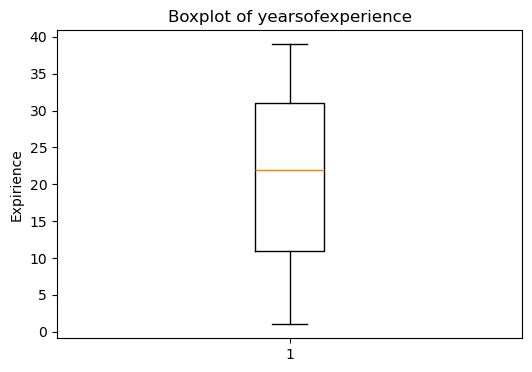

In [100]:
plt.figure(figsize=(6, 4))
plt.boxplot(d_df['yearsofexperience'].dropna())
plt.title('Boxplot of yearsofexperience')
plt.ylabel('Expirience')
plt.show()

In [101]:
upper = d_df["yearsofexperience"].quantile(0.80)
d_df["yearsofexperience"] = np.where(d_df["yearsofexperience"]> upper, upper, d_df["yearsofexperience"])

In [102]:
d_df.describe(percentiles=[0.01,0.02,0.05,0.80,0.95,0.98,0.99]).T

,count,mean,std,min,1%,2%,5%,50%,80%,95%,98%,99%,max
yearsofexperience,350.0,20.445714,10.649733,1.0,1.0,1.0,2.0,22.0,33.0,33.0,33.0,33.0,33.0


#### Hospitals Data Cleaning

In [103]:
h_df.info

<bound method DataFrame.info of   hospitalid             hospitalname       city     region
0   HOSP-001       Apex Health Centre      Delhi      North
1   HOSP-002     Sunrise Medical City     Mumbai       West
2   HOSP-003   Max Wellness Institute  Bangalore      South
3   HOSP-004  Narayana Medical Center    Kolkata       East
4   HOSP-005           AIIMS Regional     Bhopal    Central
5   HOSP-006  Medanta Super Specialty    Gurgaon      North
6   HOSP-007         Manipal Hospital    Chennai      South
7   HOSP-008             KIMS General  Hyderabad      South
8   HOSP-009         Ruby Hall Clinic       Pune       West
9   HOSP-010           GNRC Hospitals   Guwahati  Northeast>

#### Checking Null Values

In [104]:
h_df.isnull().sum()

hospitalid      0
hospitalname    0
city            0
region          0
dtype: int64

#### Checking Duplicate Values

In [105]:
h_df.duplicated().sum()

np.int64(0)

#### Saving Data in CSV Format

In [107]:
p_df.to_csv(r"C:\Users\mayan\Downloads\Health Care Project\Cleaned Data\patients.csv", index=False)

a_df.to_csv(r"C:\Users\mayan\Downloads\Health Care Project\Cleaned Data\admissions.csv", index=False)

d_df.to_csv(r"C:\Users\mayan\Downloads\Health Care Project\Cleaned Data\doctors.csv", index=False)

b_df.to_csv(r"C:\Users\mayan\Downloads\Health Care Project\Cleaned Data\billing.csv", index=False)

h_df.to_csv(r"C:\Users\mayan\Downloads\Health Care Project\Cleaned Data\hospitals.csv", index=False)

#### Connecting This Data to MySQL

In [110]:
from sqlalchemy import create_engine

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "healthcare"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")


p_df.to_sql("patients", engine, if_exists="replace", index=False)

a_df.to_sql("admissions", engine, if_exists="replace", index=False)  # Use cleaned DataFrame

d_df.to_sql("doctors", engine, if_exists="replace", index=False)

b_df.to_sql("billing", engine, if_exists="replace", index=False)

h_df.to_sql("hospitals", engine, if_exists="replace", index=False)

10

In [111]:
pd.read_sql("SHOW TABLES;", engine)

,Tables_in_healthcare
0,admissions
1,billing
2,doctors
3,hospitals
4,patients


In [112]:
pd.read_sql("SELECT * FROM patients LIMIT 5;", engine)

,patientid,firstname,lastname,age,gender,bloodtype,full_name,age_group
0,966-92-7726,Tarun,Kapoor,73,Male,O-,Tarun Kapoor,65+
1,784-20-8697,Swati,Patel,92,Female,B+,Swati Patel,65+
2,837-61-8267,Kabir,Jain,22,Male,AB+,Kabir Jain,19-35
3,882-61-6995,Vikram,Gupta,93,Male,A+,Vikram Gupta,65+
4,485-45-7437,Ishaan,Chaudhary,63,Male,AB-,Ishaan Chaudhary,51-65


In [113]:
pd.read_sql("SELECT * FROM admissions LIMIT 5;", engine)

,admissionid,patientid,doctorid,hospitalid,admissiondate,dischargedate,diagnosis,department,admissiondays,stay_category
0,ADM-000001,839-42-5034,DR-0115,HOSP-007,2023-01-22,2023-01-27,Lung Cancer,Oncology,5,Medium Treatment
1,ADM-000002,536-12-9397,DR-0314,HOSP-003,2022-08-11,2022-08-13,Coronary Artery Disease,Cardiology,2,Short Treatment
2,ADM-000003,545-47-8876,DR-0115,HOSP-007,2022-09-19,2022-10-04,Lymphoma,Oncology,15,Long Treatment
3,ADM-000004,107-58-7881,DR-0110,HOSP-008,2023-02-18,2023-03-07,Dengue,General Medicine,17,Long Treatment
4,ADM-000005,436-69-9518,DR-0121,HOSP-008,2022-12-11,2023-01-04,Melanoma,Dermatology,24,Long Treatment


In [114]:
pd.read_sql("SELECT * FROM doctors LIMIT 5;", engine)

,doctorid,hospitalid,firstname,specialty,yearsofexperience
0,DR-0001,HOSP-002,Dr. Kavya,Oncology,33.0
1,DR-0002,HOSP-004,Dr. Rohan,Neurology,22.0
2,DR-0003,HOSP-001,Dr. Riya,Dermatology,33.0
3,DR-0004,HOSP-010,Dr. Neha,Oncology,31.0
4,DR-0005,HOSP-010,Dr. Isha,Neurology,33.0


In [115]:
pd.read_sql("SELECT * FROM billing LIMIT 5;", engine)

,billid,admissionid,totalcost,diagnosis_cost,room_cost,pharmacy_cost,doctor_fee,insurancecovered,paymentstatus
0,BILL-000001,ADM-000001,118810.69,83996.55,12500.0,15564.140,6750.0,95048.55,Defaulted
1,BILL-000002,ADM-000002,56093.70,37766.23,5000.0,8727.470,4600.0,28046.85,Pending
2,BILL-000003,ADM-000003,150021.65,64611.09,37500.0,14654.555,29625.0,37619.81,Defaulted
3,BILL-000004,ADM-000004,98934.75,23430.52,42500.0,4954.230,28050.0,98934.75,Cleared
4,BILL-000005,ADM-000005,143695.78,41874.38,60000.0,8221.400,33600.0,0.00,Defaulted


In [116]:
pd.read_sql("SELECT * FROM hospitals LIMIT 5;", engine)

,hospitalid,hospitalname,city,region
0,HOSP-001,Apex Health Centre,Delhi,North
1,HOSP-002,Sunrise Medical City,Mumbai,West
2,HOSP-003,Max Wellness Institute,Bangalore,South
3,HOSP-004,Narayana Medical Center,Kolkata,East
4,HOSP-005,AIIMS Regional,Bhopal,Central


In [117]:
print(pd.read_sql("SELECT COUNT(*) FROM patients;", engine))

print(pd.read_sql("SELECT COUNT(*) FROM admissions;", engine))

print(pd.read_sql("SELECT COUNT(*) FROM doctors;", engine))

print(pd.read_sql("SELECT COUNT(*) FROM billing;", engine))

print(pd.read_sql("SELECT COUNT(*) FROM hospitals;", engine))

   COUNT(*)
0     20000
   COUNT(*)
0     20000
   COUNT(*)
0       350
   COUNT(*)
0     20000
   COUNT(*)
0        10
